In [100]:
import porepy as pp
import numpy as np
import sympy as sym

## Create mixed-dimensional grid

### Declare domain

In [101]:
domain = pp.Domain({"xmin": 0, "ymin": 0, "xmax": 1, "ymax": 1})

### Declare fracture list

In [102]:
f1 = pp.LineFracture(np.array([[0.25, 0.50], [0.50, 0.50]]))
f2 = pp.LineFracture(np.array([[0.50, 0.75], [0.50, 0.50]]))
f3 = pp.LineFracture(np.array([[0.50, 0.50], [0.25, 0.50]]))
f4 = pp.LineFracture(np.array([[0.50, 0.50], [0.50, 0.75]]))


f1_ghost = pp.LineFracture(np.array([[0.25, 0.75], [0.75, 0.75]]))
f2_ghost = pp.LineFracture(np.array([[0.75, 0.75], [0.75, 0.25]]))
f3_ghost = pp.LineFracture(np.array([[0.75, 0.25], [0.25, 0.25]]))
f4_ghost = pp.LineFracture(np.array([[0.25, 0.25], [0.25, 0.75]]))

f5_ghost = pp.LineFracture(np.array([[0.00, 0.25], [1.00, 0.75]]))
f6_ghost = pp.LineFracture(np.array([[1.00, 0.75], [1.00, 0.75]]))
f7_ghost = pp.LineFracture(np.array([[1.00, 0.75], [0.00, 0.25]]))
f8_ghost = pp.LineFracture(np.array([[0.00, 0.25], [0.00, 0.25]]))

f9_ghost = pp.LineFracture(np.array([[0.25, 0.50], [0.75, 0.50]]))
f10_ghost = pp.LineFracture(np.array([[0.75, 0.50], [0.75, 0.50]]))
f11_ghost = pp.LineFracture(np.array([[0.75, 0.50], [0.25, 0.50]]))
f12_ghost = pp.LineFracture(np.array([[0.25, 0.50], [0.25, 0.50]]))

fracs = [
    f1,
    f2,
    f3,
    f4,
    f1_ghost,
    f2_ghost,
    f3_ghost,
    f4_ghost,
    f5_ghost,
    f6_ghost,
    f7_ghost,
    f8_ghost,
    f9_ghost,
    f10_ghost,
    f11_ghost,
    f12_ghost,
]

### Construct fracture network

In [103]:
fn = pp.create_fracture_network(fracs, domain)

### Create mdg

In [104]:
meshing_args = {"cell_size": 0.05}
mdg = pp.create_mdg(
    "simplex",
    meshing_args,
    fn,
    **{"constraints": [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]})

In [105]:
mdg


Mixed-dimensional grid containing 6 grids and 8 interfaces.
Maximum dimension present: 2 
Minimum dimension present: 0 
1 grids of dimension 2 with in total 1136 cells
4 grids of dimension 1 with in total 20 cells
1 grids of dimension 0 with in total 1 cells
4 interfaces between grids of dimension 2 and 1 with in total 40 mortar cells.
4 interfaces between grids of dimension 1 and 0 with in total 4 mortar cells.

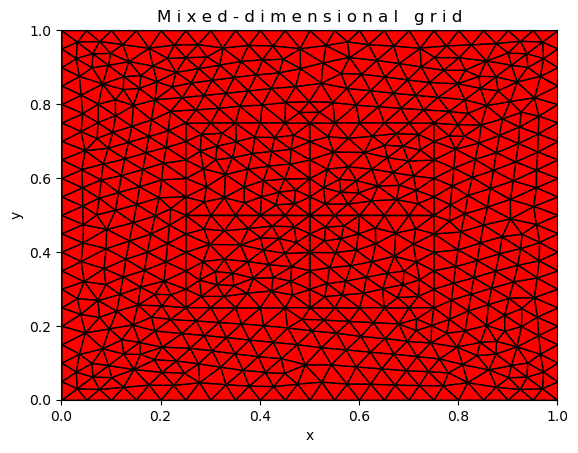

In [106]:
pp.plot_grid(mdg, plot_2d=True)

### Identify different subregions

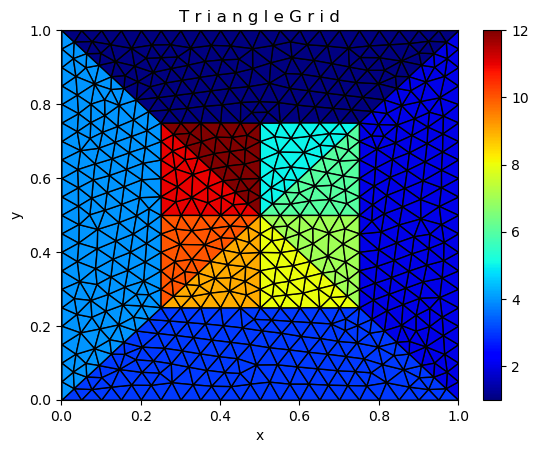

In [107]:
sd_matrix = mdg.subdomains()[0]
cc = sd_matrix.cell_centers

subregion_1 = (cc[1] > 0.75) & (cc[1] > cc[0]) & (cc[1] > 1.0 - cc[0])
subregion_2 = (cc[0] > 0.75) & (cc[0] > cc[1]) & (cc[0] > 1.0 - cc[1])
subregion_3 = (cc[1] < 0.25) & (cc[1] < cc[0]) & (cc[1] < 1.0 - cc[0])
subregion_4 = (cc[0] < 0.25) & (cc[0] < cc[1]) & (cc[0] < 1.0 - cc[1])

subregion_5 = (cc[1] < 0.75) & (cc[0] > 0.5) & (cc[1] > cc[0])
subregion_6 = (cc[0] < 0.75) & (cc[1] > 0.5) & (cc[0] > cc[1])
subregion_7 = (cc[0] < 0.75) & (cc[1] < 0.5) & (cc[0] > 1.0 - cc[1])
subregion_8 = (cc[1] > 0.25) & (cc[0] > 0.5) & (cc[0] < 1 - cc[1])
subregion_9 = (cc[1] > 0.25) & (cc[0] < 0.5) & (cc[1] < cc[0])
subregion_10 = (cc[0] > 0.25) & (cc[1] < 0.5) & (cc[1] > cc[0])
subregion_11 = (cc[0] > 0.25) & (cc[1] > 0.5) & (cc[0] < 1 - cc[1])
subregion_12 = (cc[0] < 0.50) & (cc[1] < 0.75) & (cc[0] > 1.0 - cc[1])

cc_idx = np.zeros(sd_matrix.num_cells)
cc_idx[subregion_1] = 1
cc_idx[subregion_2] = 2
cc_idx[subregion_3] = 3
cc_idx[subregion_4] = 4
cc_idx[subregion_5] = 5
cc_idx[subregion_6] = 6
cc_idx[subregion_7] = 7
cc_idx[subregion_8] = 8
cc_idx[subregion_9] = 9
cc_idx[subregion_10] = 10
cc_idx[subregion_11] = 11
cc_idx[subregion_12] = 12

pp.plot_grid(sd_matrix, cc_idx, plot_2d=True)

## Exact solution

In [108]:
x, y = sym.symbols("x y")

# Distance function
delta = [
    ((x - 0.50) ** 2 + (y - 0.75) ** 2) ** 0.50,  # subregion 1
    ((x - 0.75) ** 2 + (y - 0.50) ** 2) ** 0.50,  # subregion 2
    ((x - 0.50) ** 2 + (y - 0.25) ** 2) ** 0.50,  # subregion 3
    ((x - 0.25) ** 2 + (y - 0.50) ** 2) ** 0.50,  # subregion 4
    ((x - 0.50) ** 2) ** 0.50,  # subregion 5
    ((y - 0.50) ** 2) ** 0.50,  # subregion 6
    ((y - 0.50) ** 2) ** 0.50,  # subregion 7
    ((x - 0.50) ** 2) ** 0.50,  # subregion 8
    ((x - 0.50) ** 2) ** 0.50,  # subregion 9
    ((y - 0.50) ** 2) ** 0.50,  # subregion 10
    ((y - 0.50) ** 2) ** 0.50,  # subregion 11
    ((x - 0.50) ** 2) ** 0.50,  # subregion 12
]

# Smoother
xi = 1.5

# Bubble function
omega = [
    0,  # subregion 1
    0,  # subregion 2
    0,  # subregion 3
    0,  # subregion 4
    (y - 0.75) ** 2 * (y - 0.20) ** 2,  # subregion 5
    (x - 0.75) ** 2 * (x - 0.20) ** 2,  # subregion 6
    (x - 0.75) ** 2 * (x - 0.20) ** 2,  # subregion 7
    (y - 0.25) ** 2 * (y - 0.80) ** 2,  # subregion 8
    (y - 0.25) ** 2 * (y - 0.80) ** 2,  # subregion 9
    (x - 0.25) ** 2 * (x - 0.80) ** 2,  # subregion 10
    (x - 0.25) ** 2 * (x - 0.80) ** 2,  # subregion 11
    (y - 0.75) ** 2 * (y - 0.20) ** 2,  # subregion 12
]

# Pressure
p_6 = [delta ** (xi + 1) + omega * delta for delta, omega in zip(delta, omega)]

# Flux
q_6 = [[-sym.diff(p, x), -sym.diff(p, y)] for p in p_6]

# Mortar fluxes
lmbda_5 = omega[4]  # right of Omega_2
lmbda_6 = omega[5]  # top of Omega_3
lmbda_7 = omega[6]  # bottom of Omega_3
lmbda_8 = omega[7]  # right of Omega_4
lmbda_9 = omega[8]  # left of Omega_4
lmbda_10 = omega[9]  # bottom of Omega_5
lmbda_11 = omega[10]  # top of Omega_5
lmbda_12 = omega[11]  # left of Omega_2
 
# Fracture pressures
p_2 = -omega[4]  # vertical fracture
p_3 = -omega[5]  # horizontal fracture
p_4 = -omega[7]  # vertical fracture
p_5 = -omega[10]  # horizontal fracture

# Fracture fluxes
q_2 = -sym.diff(p_2, y)  # vertical fracture
q_3 = -sym.diff(p_3, x)  # horizontal fracture
q_4 = -sym.diff(p_4, y)  # vertical fracture
q_5 = -sym.diff(p_5, x)  # horizontal fracture

# 0-d interface fluxes
lmbda_1 = - q_2.subs({"y": 0.5})
lmbda_2 = - q_3.subs({"x": 0.5})
lmbda_3 = q_4.subs({"y": 0.5})
lmbda_4 = q_5.subs({"x": 0.5})
print("lambda_0d", lmbda_1, lmbda_2, lmbda_3, lmbda_4)

# Traces of fracture pressures @ (0.5, 0.5)
tr_p2 = p_2.subs({"y": 0.5})
tr_p3 = p_3.subs({"x": 0.5})
tr_p4 = p_4.subs({"y": 0.5})
tr_p5 = p_5.subs({"x": 0.5})
print("tr_p_1d", tr_p2, tr_p3, tr_p4, tr_p5)

# Lower dimensional pressure
p1_from_2 = tr_p2 - lmbda_1
p1_from_3 = tr_p3 - lmbda_2
p1_from_4 = tr_p4 - lmbda_3
p1_from_5 = tr_p5 - lmbda_4
print("p_0d", p1_from_2, p1_from_3, p1_from_4, p1_from_5)

lambda_0d 0.00750000000000000 0.00750000000000000 0.00750000000000001 0.00750000000000001
tr_p_1d -0.00562500000000000 -0.00562500000000000 -0.00562500000000000 -0.00562500000000000
p_0d -0.0131250000000000 -0.0131250000000000 -0.0131250000000000 -0.0131250000000000


In [109]:
# sd_2d = mdg.subdomains()[0]
# sd_1d_north = mdg.subdomains()[1]
# sd_1d_east = mdg.subdomains()[2]
# sd_1d_south = mdg.subdomains()[3]
# sd_1d_west = mdg.subdomains()[4]


In [110]:
intf = mdg.interfaces()[7]
sd_h, sd_l = mdg.interface_to_subdomain_pair(intf)
sd_h.cell_centers[0], sd_h.cell_centers[1]

(array([0.5, 0.5, 0.5, 0.5, 0.5]), array([0.525, 0.575, 0.625, 0.675, 0.725]))